In [44]:
import sys, os
from pathlib import Path
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

PROJECT_PATH = Path(r"B:\College\DL\handwriting_autocomplete_system\phase3_style_transfer")
os.chdir(PROJECT_PATH)
sys.path.insert(0, str(PROJECT_PATH))

from lib.utils import yaml2config
from lib.alphabet import strLabelConverter
from networks.BigGAN_networks import Generator
from networks.module import StyleEncoder, StyleBackbone

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT = PROJECT_PATH / 'server_files' / 'epoch_70.pth'
PRETRAINED_WID = PROJECT_PATH / 'pretrained' / 'wid_iam_new.pth'
IMG_HEIGHT, CHAR_WIDTH = 64, 32
print(f"Device: {DEVICE}")

Device: cuda


In [45]:
# Load models
cfg = yaml2config(str(PROJECT_PATH / 'configs' / 'gan_iam.yml'))
generator = Generator(**cfg.GenModel).to(DEVICE)
style_backbone = StyleBackbone(**cfg.StyBackbone).to(DEVICE)
style_encoder = StyleEncoder(**cfg.EncModel).to(DEVICE)

# Load weights
ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
generator.load_state_dict(ckpt['generator'])
style_encoder.load_state_dict(ckpt['style_encoder'])
if PRETRAINED_WID.exists():
    style_backbone.load_state_dict(torch.load(PRETRAINED_WID, map_location=DEVICE)['StyleBackbone'])

generator.eval(); style_encoder.eval(); style_backbone.eval()
label_converter = strLabelConverter('_'.join(cfg.dataset.split('_')[:2]))
print(f"Models loaded (epoch {ckpt.get('epoch', 'N/A')})")

Models loaded (epoch 70)


In [46]:
def preprocess(img_path):
    """Load and preprocess image for style extraction."""
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    h, w = img.shape
    new_w = max(int(w * IMG_HEIGHT / h), CHAR_WIDTH * 2)
    new_w = new_w + (CHAR_WIDTH - new_w % CHAR_WIDTH) % CHAR_WIDTH
    img = cv2.resize(img, (new_w, IMG_HEIGHT), interpolation=cv2.INTER_AREA if new_w < w else cv2.INTER_LINEAR)
    if img.mean() > 127: img = 255 - img  # Invert if light background
    tensor = torch.from_numpy((img / 255.0 - 0.5) / 0.5).float().unsqueeze(0).unsqueeze(0)
    return tensor, new_w

def to_image(tensor):
    """Convert tensor to displayable image."""
    img = tensor.squeeze().cpu().numpy()
    return np.clip((1 - (img + 1) / 2) * 255, 0, 255).astype(np.uint8)

@torch.no_grad()
def generate(style_img_path, texts):
    """Generate handwriting with given style and texts."""
    img_tensor, width = preprocess(style_img_path)
    img_tensor = img_tensor.to(DEVICE)
    style = style_encoder(img_tensor, torch.tensor([width]).to(DEVICE), style_backbone, vae_mode=False)
    
    results = []
    for text in texts:
        lbs, lb_lens = label_converter.encode([text])
        fake = generator(style, lbs.to(DEVICE), lb_lens.to(DEVICE))
        results.append((text, to_image(fake)))
    return results

In [47]:
# === Generate ===
STYLE_IMAGE = PROJECT_PATH / 'inference' / 'input' / 'sample.png'  # Your style reference
TEXTS = ['hello', 'world', 'python', 'neural', 'network']

if STYLE_IMAGE.exists():
    results = generate(STYLE_IMAGE, TEXTS)
    
    fig, axes = plt.subplots(len(results) + 1, 1, figsize=(12, 2 * (len(results) + 1)))
    ref = cv2.imread(str(STYLE_IMAGE), cv2.IMREAD_GRAYSCALE)
    axes[0].imshow(ref, cmap='gray'); axes[0].set_title('Reference Style'); axes[0].axis('off')
    
    for i, (text, img) in enumerate(results):
        axes[i+1].imshow(img, cmap='gray'); axes[i+1].set_title(f'"{text}"'); axes[i+1].axis('off')
    
    plt.tight_layout(); plt.show()
else:
    print(f"Put a style reference image at: {STYLE_IMAGE}")

Put a style reference image at: B:\College\DL\handwriting_autocomplete_system\phase3_style_transfer\inference\input\sample.png


In [48]:
# === Batch process all images in input folder ===
INPUT_DIR = PROJECT_PATH / 'inference' / 'input'
OUTPUT_DIR = PROJECT_PATH / 'inference' / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for img_path in INPUT_DIR.glob('*.png'):
    results = generate(img_path, TEXTS)
    
    fig, axes = plt.subplots(1, len(results), figsize=(3 * len(results), 2))
    for i, (text, img) in enumerate(results):
        axes[i].imshow(img, cmap='gray'); axes[i].set_title(text); axes[i].axis('off')
    
    plt.savefig(OUTPUT_DIR / f'{img_path.stem}_generated.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Processed: {img_path.name}")

print(f"Done! Results in {OUTPUT_DIR}")

Processed: image.png
Processed: jumps.png
Processed: Screenshot 2025-11-26 232829.png
Done! Results in B:\College\DL\handwriting_autocomplete_system\phase3_style_transfer\inference\output


## Loss Plots from Training History

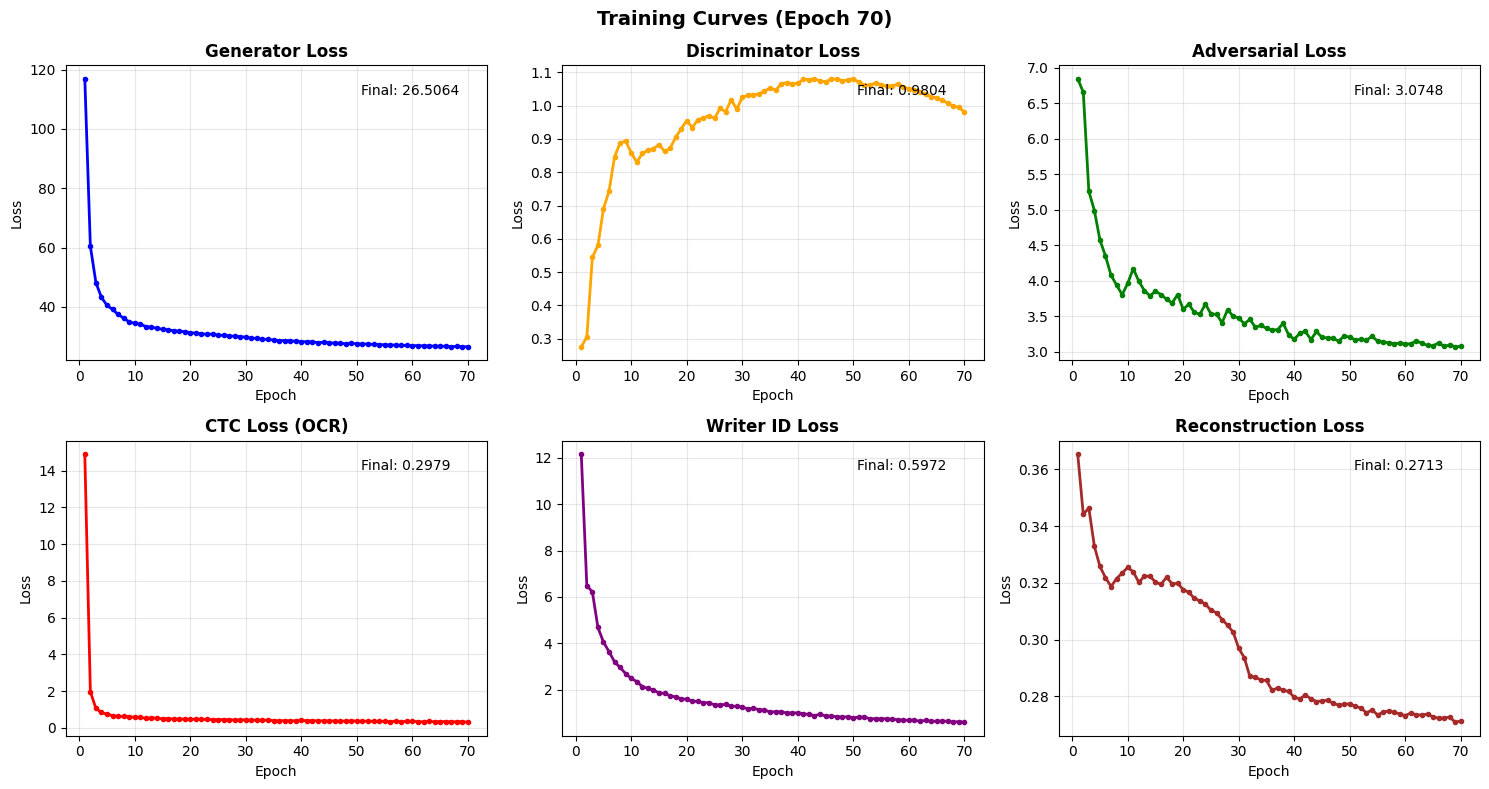

Loss curves saved to loss_curves.png


In [49]:
# Plot training losses from checkpoint
history = ckpt.get('history', {})
if history and history.get('epoch'):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    plots = [
        ('g_loss', 'Generator Loss', 'blue'),
        ('d_loss', 'Discriminator Loss', 'orange'),
        ('adv_loss', 'Adversarial Loss', 'green'),
        ('ctc_loss', 'CTC Loss (OCR)', 'red'),
        ('wid_loss', 'Writer ID Loss', 'purple'),
        ('recn_loss', 'Reconstruction Loss', 'brown')
    ]
    
    for ax, (key, title, color) in zip(axes.ravel(), plots):
        if key in history and history[key]:
            ax.plot(history['epoch'], history[key], color=color, linewidth=2, marker='o', markersize=3)
            ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
            ax.set_title(title, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.annotate(f'Final: {history[key][-1]:.4f}', xy=(0.7, 0.9), xycoords='axes fraction')
    
    plt.suptitle(f'Training Curves (Epoch {ckpt.get("epoch", "N/A")})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROJECT_PATH / 'loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Loss curves saved to loss_curves.png")
else:
    print("No training history in checkpoint")

## Inference on Original Dataset

In [50]:
# Load test dataset and generate reconstructions
from lib.datasets import get_dataset, get_collect_fn
from torch.utils.data import DataLoader
from networks.module import Recognizer, WriterIdentifier

# Load test set
collect_fn = get_collect_fn(cfg.training.sort_input, sort_style=True)
test_dataset = get_dataset(cfg.valid.dset_name, cfg.valid.dset_split, recogn_aug=False, wid_aug=False, process_style=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collect_fn, num_workers=0)
print(f"Test samples: {len(test_dataset)}")

# Load recognizer for CER/WER
recognizer = Recognizer(**cfg.OcrModel).to(DEVICE)
if (PROJECT_PATH / cfg.training.pretrained_r).exists():
    recognizer.load_state_dict(torch.load(PROJECT_PATH / cfg.training.pretrained_r, map_location=DEVICE)['Recognizer'])
recognizer.eval()

# Load writer identifier
writer_id = WriterIdentifier(**cfg.WidModel).to(DEVICE)
if PRETRAINED_WID.exists():
    writer_id.load_state_dict(torch.load(PRETRAINED_WID, map_location=DEVICE)['WriterIdentifier'])
writer_id.eval()
print("Auxiliary models loaded")

Test samples: 11170
Auxiliary models loaded


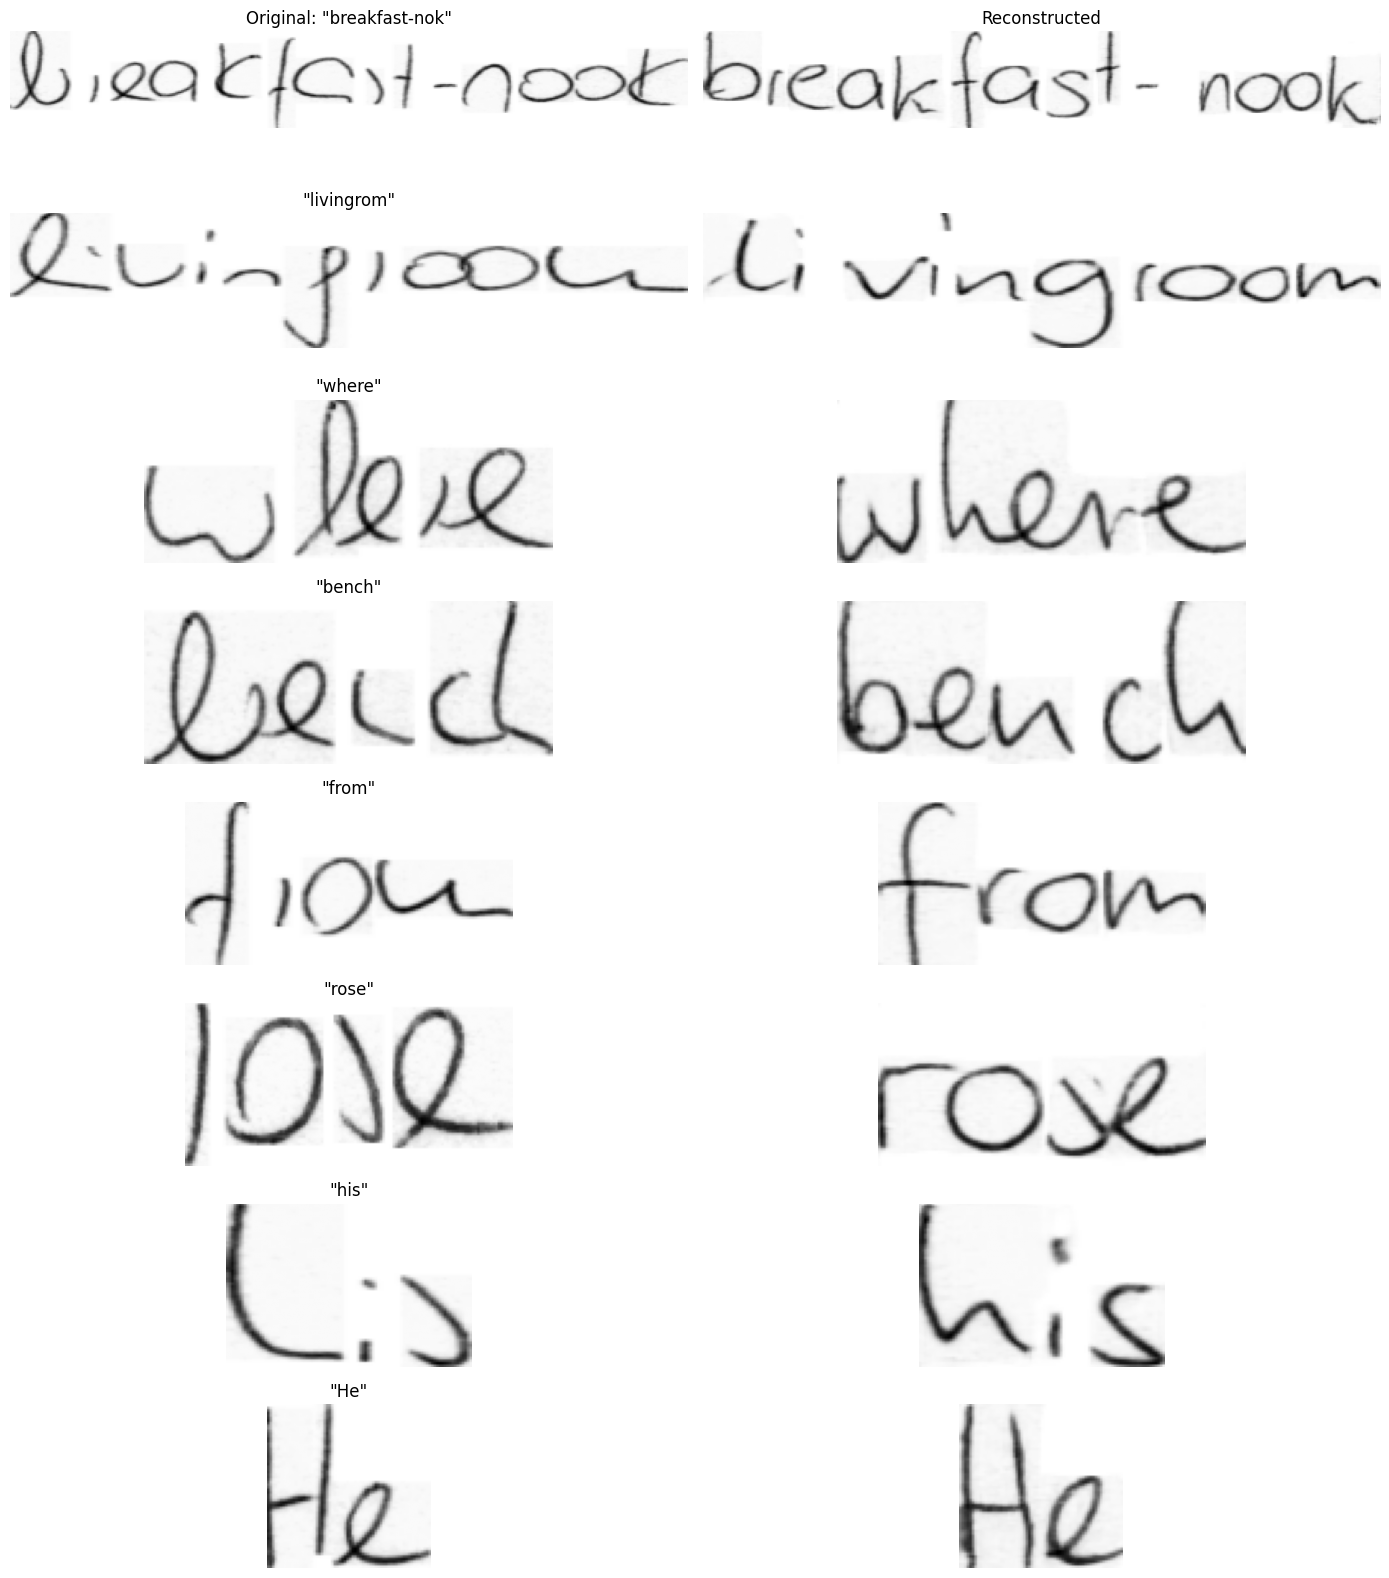

In [51]:
# Generate reconstructions on test set and visualize samples
@torch.no_grad()
def generate_reconstructions(loader, n_samples=8):
    """Generate reconstructed images from test set."""
    batch = next(iter(loader))
    real_imgs = batch['style_imgs'].to(DEVICE)
    real_img_lens = batch['style_img_lens'].to(DEVICE)
    real_lbs = batch['lbs'].to(DEVICE)
    real_lb_lens = batch['lb_lens'].to(DEVICE)
    
    # Encode style and reconstruct
    enc_z = style_encoder(real_imgs, real_img_lens, style_backbone, vae_mode=False)
    recn_imgs = generator(enc_z, real_lbs, real_lb_lens)
    
    # Decode labels
    texts = label_converter.decode(real_lbs.cpu(), real_lb_lens.cpu())
    
    return real_imgs[:n_samples], recn_imgs[:n_samples], real_img_lens[:n_samples], texts[:n_samples]

real, recon, lens, texts = generate_reconstructions(test_loader)

# Visualize
fig, axes = plt.subplots(min(8, len(real)), 2, figsize=(14, 2*min(8, len(real))))
for i in range(min(8, len(real))):
    w = lens[i].item()
    # Original
    orig = ((real[i, 0, :, :w].cpu().numpy() + 1) / 2)
    axes[i, 0].imshow(1 - orig, cmap='gray'); axes[i, 0].axis('off')
    axes[i, 0].set_title(f'Original: "{texts[i]}"' if i == 0 else f'"{texts[i]}"')
    # Reconstructed
    rec = ((recon[i, 0, :, :w].cpu().numpy() + 1) / 2)
    axes[i, 1].imshow(1 - rec, cmap='gray'); axes[i, 1].axis('off')
    axes[i, 1].set_title('Reconstructed' if i == 0 else '')

plt.tight_layout()
plt.savefig(PROJECT_PATH / 'reconstruction_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Metrics Calculation (FID, KID, IS, CER, WER, WIER, MSSIM, PSNR)

Creating style interpolation GIF...
Text: 'Deep Learning Is Fun'
This may take a moment...

✓ GIF saved to: B:\College\DL\handwriting_autocomplete_system\phase3_style_transfer\inference\style_interpolation.gif
  Total frames: 120
  Duration: 4.0 seconds (fast loop!)


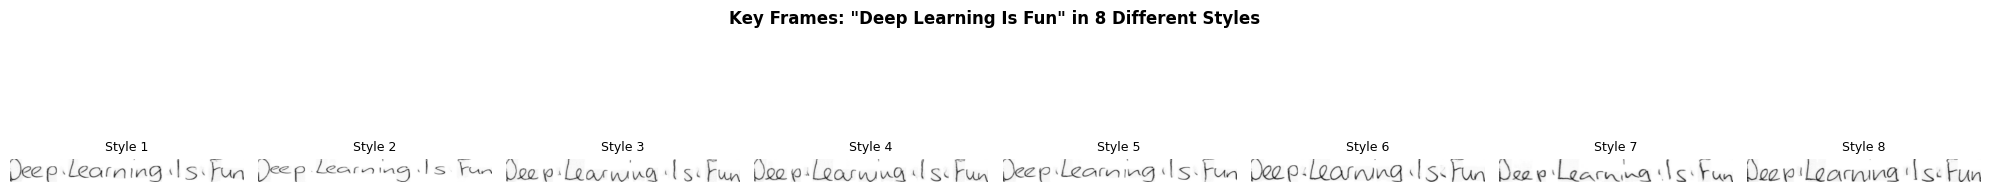

Key frames saved to style_interpolation_keyframes.png


In [52]:
# Style interpolation GIF - smoothly morph between different writing styles
from PIL import Image
import imageio

@torch.no_grad()
def create_style_interpolation_gif(loader, text="DEEP LEARNING IS FUN", n_styles=8, n_frames=15, fps=30):
    """Create a GIF showing smooth interpolation between different writing styles."""
    
    # Get multiple style samples from test set
    batch = next(iter(loader))
    real_imgs = batch['style_imgs'].to(DEVICE)[:n_styles]
    real_img_lens = batch['style_img_lens'].to(DEVICE)[:n_styles]
    
    # Extract style vectors
    styles = style_encoder(real_imgs, real_img_lens, style_backbone, vae_mode=False)
    
    # Encode target text
    lbs, lb_lens = label_converter.encode([text])
    lbs, lb_lens = lbs.to(DEVICE), lb_lens.to(DEVICE)
    
    frames = []
    
    # Interpolate between consecutive styles (loop back to first)
    for style_idx in range(n_styles):
        next_idx = (style_idx + 1) % n_styles
        style_a = styles[style_idx:style_idx+1]
        style_b = styles[next_idx:next_idx+1]
        
        for frame in range(n_frames):
            # Smooth easing interpolation (ease in-out)
            t = frame / n_frames
            alpha = t * t * (3 - 2 * t)  # Smoothstep
            interpolated_style = (1 - alpha) * style_a + alpha * style_b
            
            # Generate image
            fake = generator(interpolated_style, lbs, lb_lens)
            img = ((fake[0, 0].detach().cpu().numpy() + 1) / 2)
            img = (1 - img) * 255  # Invert for white background
            img = np.clip(img, 0, 255).astype(np.uint8)
            
            # Add text label and frame info
            h, w = img.shape
            # Pad image for labels
            padded = np.ones((h + 40, w, 3), dtype=np.uint8) * 255
            padded[20:20+h, :, :] = np.stack([img]*3, axis=-1)
            
            frames.append(padded)
    
    # Save as GIF
    gif_path = PROJECT_PATH / 'inference/style_interpolation.gif'
    imageio.mimsave(str(gif_path), frames, fps=fps, loop=0)
    
    return gif_path, len(frames)

# Create the interpolation GIF
print("Creating style interpolation GIF...")
print(f"Text: 'Deep Learning Is Fun'")
print("This may take a moment...")

gif_path, total_frames = create_style_interpolation_gif(
    test_loader, 
    text="Deep Learning Is Fun",
    n_styles=8,      # More styles for variety
    n_frames=15,     # Frames between each style pair
    fps=30           # Faster playback
)

duration = total_frames / 30
print(f"\n✓ GIF saved to: {gif_path}")
print(f"  Total frames: {total_frames}")
print(f"  Duration: {duration:.1f} seconds (fast loop!)")

# Also display a preview of key frames
fig, axes = plt.subplots(1, 8, figsize=(20, 3))

# Regenerate key frames for display
batch = next(iter(test_loader))
real_imgs = batch['style_imgs'].to(DEVICE)[:8]
real_img_lens = batch['style_img_lens'].to(DEVICE)[:8]
with torch.no_grad():
    styles = style_encoder(real_imgs, real_img_lens, style_backbone, vae_mode=False)
    lbs, lb_lens = label_converter.encode(["Deep Learning Is Fun"])
    lbs, lb_lens = lbs.to(DEVICE), lb_lens.to(DEVICE)

    for i, ax in enumerate(axes):
        fake = generator(styles[i:i+1], lbs, lb_lens)
        img = ((fake[0, 0].cpu().numpy() + 1) / 2)
        ax.imshow(1 - img, cmap='gray')
        ax.set_title(f'Style {i+1}', fontsize=9)
        ax.axis('off')

plt.suptitle('Key Frames: "Deep Learning Is Fun" in 8 Different Styles', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_PATH / 'inference/style_interpolation_keyframes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Key frames saved to style_interpolation_keyframes.png")